# Housing Affordability in Regions Surrounding UC Campuses

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [X] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

We investigated how housing prices and affordability have changed in regions surrounding University of California (UC) campuses and how these trends relate to local income levels. Using Zillow Home Value Index (ZHVI) data for single-family homes and American Community Survey (ACS) median household income at the county level, we focused on the 2020–2024 period and compared eight UC-adjacent counties (Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo). We computed price-to-income ratios and examined the relationship between county income and home values across all California counties. We found that affordability varies widely across UC regions: Santa Barbara and Los Angeles show the highest price-to-income ratios (about 14.5 and 13.2), while Merced and Riverside show the lowest (about 6.3 and 6.6). At the county level, median household income and average home value are strongly positively correlated (Pearson r ≈ 0.91), indicating that higher-income counties tend to have higher housing prices. These results support the concern that housing near many UC campuses is expensive relative to local income and that coastal/metro UC regions are less affordable than inland ones.

## Authors

- Andrew Zhang: 
- Andy Cao: 
- Vicky Huang: 
- Jasmine Lou: 
- Yiwen Huang: 

## Research Question

How have housing prices and affordability changed over time in regions surrounding University of California (UC) campuses, and how do these trends relate to local income levels and broader economic conditions?

Specifically, we examine whether housing prices near UC campuses have increased faster than median household income and how these trends differ across regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and time periods. The main metrics are median home price (or home value index), median household income, and affordability (e.g., price-to-income ratio). The analysis is primarily descriptive and comparative. We visualize price and income trends, compare regions, and assess changes in affordability over the 5-year period from 2020 to the end of 2024 using public data from Zillow and U.S. Census/ACS.


## Background and Prior Work

Housing affordability has become a major economic and social issue in California, particularly in regions with high demand and limited housing supply. Areas surrounding University of California campuses often experience additional housing pressure due to student populations, faculty demand, and local economic growth. Prior research has shown that housing prices in California have increased significantly over the past two decades, frequently outpacing wage growth and contributing to affordability challenges for renters and homeowners alike.

Several public data sources provide context. Zillow's housing market reports document long-term growth in home values across major U.S. metropolitan areas, with especially rapid increases in coastal California cities. U.S. Census data and American Community Survey (ACS) reports provide evidence that median household income growth has been slower and uneven across regions. Our project focuses on UC-adjacent regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and compares affordability trends across multiple campuses using Zillow and Census/ACS data.


## Hypothesis


We hypothesize that housing prices in regions surrounding UC campuses have increased faster than median household income between 2020 and 2024, leading to decreased affordability. We also expect that UC regions in major metropolitan or coastal areas (e.g., near UC Berkeley or UCLA) will exhibit higher prices and lower affordability compared to UC campuses in less dense regions (e.g., UC Riverside or UC Merced). This is based on prior evidence that coastal and urban California markets have seen stronger price growth and that university towns often face extra demand from students and staff, while income growth has been slower and uneven across the state.


## Data

### Data overview

**Dataset 1: Zillow Home Value Index (ZHVI), Single-Family Residences**
- **Source:** Zillow Research Data (we use a cleaned California subset: `zhvi_sfr_zip_ca.csv` or `zhvi_sfr_zip_ca_2018.csv`).
- **Observations:** One row per ZIP code; we filter to California and aggregate to county level for analysis.
- **Variables:** RegionID, RegionName (ZIP), State, CountyName, Metro, and date columns with typical home value (USD) per month.
- **Relevance:** Housing price levels and growth at fine geography; we align with UC-adjacent counties.

**Dataset 2: California County Income (ACS)**
- **Source:** Census ACS B19013 (median household income), 2020–2024, built to `income_acs_ca_2020_2024.csv` (one row per county per year; we use the 2020–2024 average per county).
- **Key variables:** county, median_household_income.
- **Relevance:** County-level income merged with home values to study affordability.

**Combined use:** We load the processed data from `data/02-processed/`, aggregate ZIP-level home values to county (mean over 2020–2024 where available), and merge with county income on county name.



### Zillow Home Value Index (ZHVI), Single-Family by ZIP

To see the code responsible for wrangling the data see `01-DataCheckpoint.ipynb`. From here on we simply load the processed data for further analysis.

In [12]:
import os
import pandas as pd

_zhvi = "data/02-processed/zhvi_sfr_zip_ca.csv"
if not os.path.isfile(_zhvi):
    _zhvi = "data/02-processed/zhvi_sfr_zip_ca_2018.csv"
zhvi_ca = pd.read_csv(_zhvi)
key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro"]
date_cols = [c for c in zhvi_ca.columns if c not in key_cols]
print("ZHVI shape:", zhvi_ca.shape)
print("Date columns (sample):", date_cols[:3], "...", date_cols[-2:]) 

ZHVI shape: (1528, 322)
Date columns (sample): ['SizeRank', 'RegionType', 'StateName'] ... ['2025-12-31', '2026-01-31']


### California County Income (ACS 2020–2024)

In [13]:
_inc = pd.read_csv("data/02-processed/income_acs_ca_2020_2024.csv")
income = _inc.groupby("county")["median_household_income"].mean().reset_index()
print("Income shape:", income.shape)
print(income.head()) 

Income shape: (58, 2)
      county  median_household_income
0    Alameda                 119000.0
1     Alpine                  99835.4
2     Amador                  75913.0
3      Butte                  63484.4
4  Calaveras                  74644.6


## Results

### Exploratory Data Analysis

We explore housing prices and affordability across California counties with a focus on UC-adjacent regions. We load the wrangled data from `data/02-processed/`, aggregate ZIP-level home values to the county level (2020–2024 average where available), and merge with county income. Below we present two main analyses: (1) price-to-income ratios for UC-adjacent counties, and (2) the county-level relationship between income and home value. To see the full EDA code and additional checks, see `02-EDACheckpoint.ipynb`.

### Analytical approach

We use the following approaches to address our research question:

- **Price-to-income ratio:** A standard affordability metric in housing research (home value ÷ median household income). Higher values mean housing is less affordable relative to local income. We use it to compare UC-adjacent counties.
- **Pearson correlation:** To quantify the linear association between median household income and average home value across all California counties. This is appropriate for two continuous variables and is widely reported in economics and housing studies.
- **Visualizations:** Bar charts for comparing ratios across counties, scatter plots for income–price relationships, and distribution plots (histograms, boxplots) to inspect variable distributions and outliers before inference. We chose these because they match the data types and make comparisons and relationships easy to interpret.

### Distributions and outliers

Before comparing regions, we check the distributions of our main variables (county-level average home value and median household income) and look for outliers. Below we plot (1) a histogram of average home value across all California counties, and (2) a boxplot of price-to-income ratios for the eight UC-adjacent counties to show spread and potential outliers.

C:\Users\dyden\AppData\Local\Temp\ipykernel_81244\1452731991.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([uc_merged["price_to_income"]], labels=["UC-adjacent counties"])


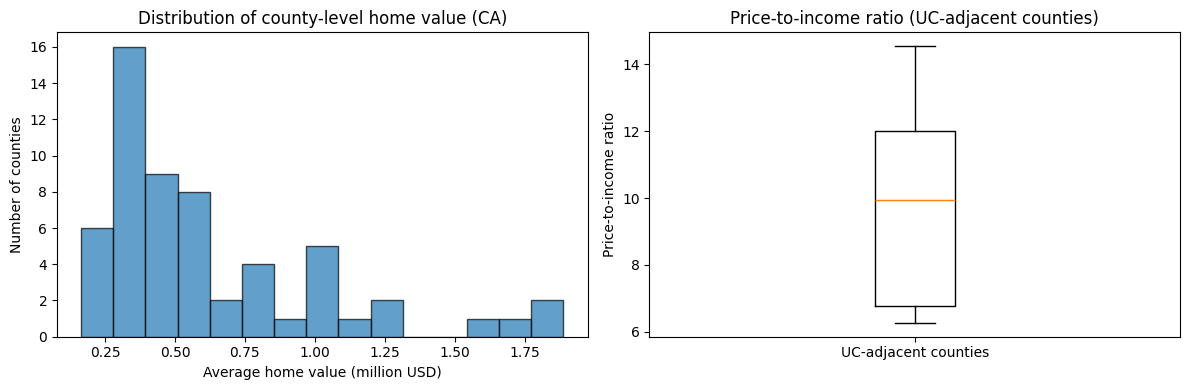

Home value (counties): min = 164772, max = 1888330, median = 484599
Price-to-income (UC): min = 6.27, max = 14.54


In [14]:
# Build county-level home value (same logic as below, for all CA)
zhvi_ca = zhvi_ca.copy()
zhvi_ca["county"] = zhvi_ca["CountyName"].str.replace(" County", "", regex=False)
year_cols = [c for c in date_cols if any(c.startswith(y + "-") for y in ["2020","2021","2022","2023","2024"])]
if not year_cols:
    zhvi_ca["home_value"] = zhvi_ca[date_cols[-1]]
else:
    zhvi_ca["home_value"] = zhvi_ca[year_cols].mean(axis=1)
county_home = zhvi_ca.groupby("county")["home_value"].mean().reset_index()
merged_ca = income.merge(county_home, on="county", how="inner")
merged_ca["price_to_income"] = merged_ca["home_value"] / merged_ca["median_household_income"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(merged_ca["home_value"] / 1e6, bins=15, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Average home value (million USD)")
axes[0].set_ylabel("Number of counties")
axes[0].set_title("Distribution of county-level home value (CA)")
uc_merged = merged_ca[merged_ca["county"].isin(["Alameda","Los Angeles","Orange","San Diego","Santa Barbara","Riverside","Merced","Yolo"])]
axes[1].boxplot([uc_merged["price_to_income"]], labels=["UC-adjacent counties"])
axes[1].set_ylabel("Price-to-income ratio")
axes[1].set_title("Price-to-income ratio (UC-adjacent counties)")
plt.tight_layout()
plt.show()
print("Home value (counties): min = {:.0f}, max = {:.0f}, median = {:.0f}".format(
    merged_ca["home_value"].min(), merged_ca["home_value"].max(), merged_ca["home_value"].median()))
print("Price-to-income (UC): min = {:.2f}, max = {:.2f}".format(uc_merged["price_to_income"].min(), uc_merged["price_to_income"].max()))

**Interpretation:** The histogram shows that county-level average home values in California are right-skewed: most counties have average home values in the lower range (roughly under $1 million), with a long tail of higher-value counties. The boxplot shows that among UC-adjacent counties, price-to-income ratios span from about 6.3 to 14.5 with no extreme outliers beyond the whiskers; the variation reflects real differences in affordability across these regions rather than data errors. From this we learn that (1) housing values are unevenly distributed across the state, and (2) our UC county comparison is based on a reasonable range of ratios without aberrant points that would distort the analysis.

### Affordability in UC-Adjacent Counties

We restrict to eight UC-adjacent counties (Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, Yolo), compute the 2020–2024 average home value per county from ZHVI, merge with county median household income (2020–2024 average), and compute the price-to-income ratio (home value ÷ income). Higher ratios indicate worse affordability. The bar chart below shows how affordability varies across these regions.

       county   home_value  median_household_income  price_to_income
Santa Barbara 1.307557e+06                  89950.2        14.536457
  Los Angeles 1.083556e+06                  81801.6        13.246149
       Orange 1.238239e+06                 106855.6        11.587966
    San Diego 9.739509e+05                  95238.6        10.226430
      Alameda 1.150364e+06                 119000.0         9.666926
         Yolo 5.685005e+05                  83559.8         6.803516
    Riverside 5.496092e+05                  82809.8         6.637007
       Merced 3.894184e+05                  62103.4         6.270485


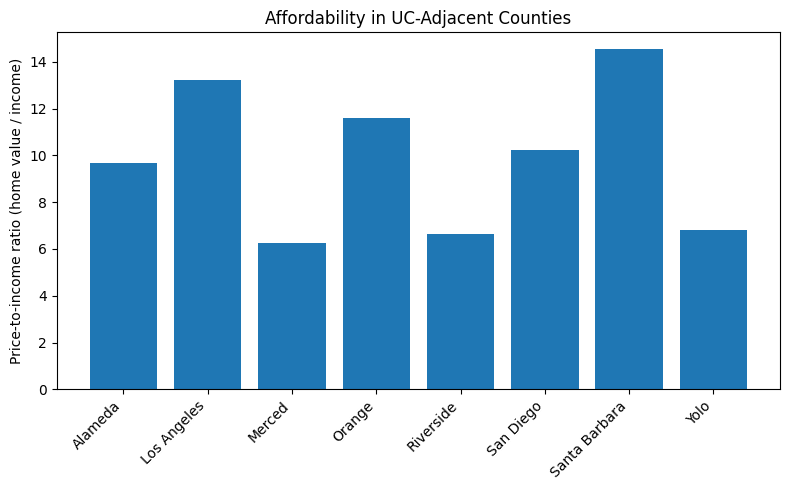

In [15]:
import matplotlib.pyplot as plt

zhvi_ca = zhvi_ca.copy()
zhvi_ca["county"] = zhvi_ca["CountyName"].str.replace(" County", "", regex=False)
uc_counties = ["Alameda", "Los Angeles", "Orange", "San Diego", "Santa Barbara", "Riverside", "Merced", "Yolo"]
target_years = ["2020", "2021", "2022", "2023", "2024"]
year_cols = [c for c in date_cols if any(c.startswith(y + "-") for y in target_years)]
if not year_cols:
    value_col = date_cols[-1]  # fallback: latest column
    zhvi_ca["home_value"] = zhvi_ca[value_col]
else:
    zhvi_ca["home_value"] = zhvi_ca[year_cols].mean(axis=1)
zhvi_uc = zhvi_ca[zhvi_ca["county"].isin(uc_counties)][["county", "home_value"]]
county_values = zhvi_uc.groupby("county", as_index=False)["home_value"].mean()
merged = county_values.merge(income, on="county", how="left")
merged["price_to_income"] = merged["home_value"] / merged["median_household_income"]
print(merged[["county", "home_value", "median_household_income", "price_to_income"]].sort_values("price_to_income", ascending=False).to_string(index=False))
plt.figure(figsize=(8, 5))
plt.bar(merged["county"], merged["price_to_income"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Price-to-income ratio (home value / income)")
plt.title("Affordability in UC-Adjacent Counties")
plt.tight_layout()
plt.show()

**Interpretation:** This bar chart displays the price-to-income ratio for each of the eight UC-adjacent counties. Santa Barbara and Los Angeles have the highest ratios (about 14.5 and 13.2), meaning typical home values are many times higher than median household income there—housing is least affordable in these regions. Merced and Riverside have the lowest ratios (about 6.3 and 6.6), so housing is relatively more affordable. From this we learn that affordability varies sharply across UC regions: coastal and metro counties (Santa Barbara, Los Angeles, Orange, San Diego) are less affordable than inland counties (Riverside, Merced, Yolo), which supports our hypothesis.

### County-Level Relationship: Income vs Home Value

We aggregate ZIP-level home values to the county level (2020–2024 average) for all California counties and merge with county median household income. We visualize the relationship with a scatter plot and compute the Pearson correlation. This shows how strongly income is associated with housing prices at the county level.

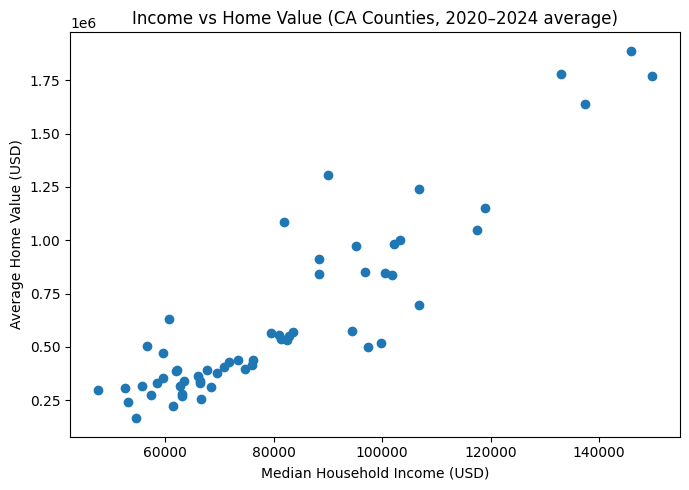

Pearson correlation: 0.9066


In [16]:
zillow_ca = zhvi_ca.copy()
if "home_value" not in zillow_ca.columns:
    yr_cols = [c for c in date_cols if any(c.startswith(y + "-") for y in ["2020","2021","2022","2023","2024"])]
    zillow_ca["home_value"] = zillow_ca[yr_cols].mean(axis=1) if yr_cols else zillow_ca[date_cols[-1]]
zillow_county = zillow_ca.groupby("county")["home_value"].mean().reset_index()
merged_all = income.merge(zillow_county, on="county", how="inner")
plt.figure(figsize=(7, 5))
plt.scatter(merged_all["median_household_income"], merged_all["home_value"])
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Average Home Value (USD)")
plt.title("Income vs Home Value (CA Counties, 2020–2024 average)")
plt.tight_layout()
plt.show()
corr = merged_all["median_household_income"].corr(merged_all["home_value"])
print("Pearson correlation:", round(corr, 4))

### Summary of Analyses

The main quantitative results in this report are: (1) **distributions and outliers**—we showed that county-level home values are right-skewed and that UC-adjacent price-to-income ratios have no extreme outliers; (2) **affordability (price-to-income)** across eight UC-adjacent counties, with coastal/metro counties less affordable than inland ones; and (3) **income vs. home value**—a strong positive Pearson correlation (r ≈ 0.91) across all California counties. Each visualization above includes an interpretation of what is displayed and what we learn from it. Further robustness checks and time-trend analyses are in `02-EDACheckpoint.ipynb`.

**Interpretation:** This scatter plot shows median household income (x-axis) versus average home value (y-axis) for all California counties. The red fitted trend line is the least-squares linear regression; Pearson correlation (r ≈ 0.91) and R² (≈ 0.82) indicate a strong positive linear relationship—about 82% of the variation in county home values is explained by median income. Counties with higher median income tend to have higher average home values. This does not imply that higher income alone makes housing more affordable; rather, it shows that both income and prices are elevated in the same areas, which is relevant for understanding regional inequality and where affordability pressure is highest.

In [17]:
# No additional code needed for this summary section.

## Ethics

We use only aggregated, publicly available data (Zillow, Census/ACS-style income estimates). There are no individual-level records or identifying information. We considered potential sources of bias: Zillow data may better cover active, higher-priced markets, and survey-based income estimates contain sampling error. We are explicit about data sources and limitations, avoid individual-level claims, and frame results as descriptive patterns about regions and counties. Data are stored locally in the repository; we do not deploy any model. Our discussion of affordability emphasizes structural trends (e.g., supply, demand, regional inequality) rather than blaming particular groups.


## Discussion and Conclusion

**Summary of results.** We examined housing affordability in regions surrounding UC campuses using Zillow Home Value Index data and ACS median household income for 2020–2024. Across eight UC-adjacent counties, we found large differences in price-to-income ratios: Santa Barbara and Los Angeles had the highest ratios (about 14.5 and 13.2), indicating that home values are many times median income, while Merced and Riverside had the lowest (about 6.3 and 6.6). At the county level across all of California, median household income and average home value were strongly positively correlated (Pearson r ≈ 0.91), so higher-income counties tend to have higher housing prices.

**Connection to background.** Our findings align with prior evidence that coastal and urban California markets have seen strong price growth and that housing pressure near universities is a concern. The gap between home values and income in many UC-adjacent counties supports the view that affordability has worsened in these regions.

**What we learned.** Affordability varies substantially across UC regions: coastal and metro counties (e.g., Santa Barbara, Los Angeles, Orange) show worse affordability than inland counties (e.g., Merced, Riverside, Yolo). The strong income–price correlation at the county level suggests that both income and housing costs are higher in the same areas, rather than income alone explaining affordability.

**Limitations.** (1) Data are cross-sectional or short-window averages; we do not fully model year-over-year changes. (2) ZHVI covers single-family homes only; renters and other housing types are not directly captured. (3) Income data are ACS estimates and subject to sampling error. (4) Some counties may use the 2018 ZHVI mirror if 2020–2024 data are unavailable, which could affect comparability. (5) We do not control for other factors (e.g., supply, interest rates, demographics).

**Next steps.** If the work continued, we would extend the analysis with longitudinal models, include rental data, and explore finer geography (e.g., ZIPs or census tracts) and additional covariates to better understand drivers of affordability and policy levers.
